<a href="https://colab.research.google.com/github/thanvika05/Thanvika_CodeBooster_2026/blob/main/Day3/Mini_proj3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
API_KEY = "ae41f8f1d11abf2d79659d4ff83acb98"

BASE_URL = "https://openweathermap.org/data/2.5/weather"

CITIES = ['Mumbai','Delhi','Bengaluru','Chennai','Hyderabad','Kolkata','Pune',"Jaipur"]

print(f"API configured for {len(CITIES)} cities")
print(f"Cities: {CITIES}")

API configured for 8 cities
Cities: ['Mumbai', 'Delhi', 'Bengaluru', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [6]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrices, or None on failure.
  """
  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params = params, timeout=10)

    if response.status_code==200:

      data = response.json()

      return{
          'city': city,
          'temperature' : round(data['main']['temp'], 1),
          'feels_like' : round(data['main']['feels_like'], 1),
          'humidity' : data['main']['humidity'],
          'pressure' : data['main']['pressure'],
          'wind_speed' : data['wind']['speed'],
          'condition' : data['weather'][0]['description'].title(),
          'visibility' : data.get('visibility', 0)
      }
    else:
      print(f' ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}')
      return None
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
    return None

  except requests.exceptions.Timeout:
    print(f'TIMEOUT ERROR for {city} - API did not respond in 10 seconds')
    return None

print("Calling Weathe API...")
weather_records=[]

for city in CITIES:
  print(f' Fetching: {city}...', end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f'{record['temperature']}°C', {record['condition']})
    print(record)
  else:
    print('FAILED')
print(f'\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities')

Calling Weathe API...
 Fetching: Mumbai... ERROR 401 for Mumbai: Invalid API key. Please see http://openweathermap.org/faq#error401 for more info.
FAILED
 Fetching: Delhi... ERROR 401 for Delhi: Invalid API key. Please see http://openweathermap.org/faq#error401 for more info.
FAILED
 Fetching: Bengaluru... ERROR 401 for Bengaluru: Invalid API key. Please see http://openweathermap.org/faq#error401 for more info.
FAILED
 Fetching: Chennai... ERROR 401 for Chennai: Invalid API key. Please see http://openweathermap.org/faq#error401 for more info.
FAILED
 Fetching: Hyderabad... ERROR 401 for Hyderabad: Invalid API key. Please see http://openweathermap.org/faq#error401 for more info.
FAILED
 Fetching: Kolkata... ERROR 401 for Kolkata: Invalid API key. Please see http://openweathermap.org/faq#error401 for more info.
FAILED
 Fetching: Pune... ERROR 401 for Pune: Invalid API key. Please see http://openweathermap.org/faq#error401 for more info.
FAILED
 Fetching: Jaipur... ERROR 401 for Jaipur: I

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
if len(weather_records)==0:
  print("Using fallback data for plotting")
else:
  data = weather_records
  pdf = pd.DataFrame(weather_records)
  print(pdf)
  print("-"*80)
  print(pdf.to_string(index=False))
  print(f"\nShape : ",pdf.shape)
  print(f"\nMissing Values : ",pdf.isnull().sum())
  print(f'\nData Types : ')
  print(pdf.dtypes)

Using fallback data for plotting


In [10]:
import requests
def fetch_weather(city, api_key):
  params={
      'q':city,
      'appid':api_key,
      'units':'metric'
  }

  try:
    response=requests.get(BASE_URL,params=params,timeout=10)

    if response.status_code==200:
      data=response.json()

      return{
          'city': city,
          'temperature':round(data['main']['temp'],1),
          'description':data['weather'][0]['description'],
          'humidity':data['main']['humidity'],
          'wind_speed':data['wind']['speed'],
          'pressure': data['main']['pressure'],
          'condition':data['weather'][0]['description'].title(),
          'visibility':data.get('visibility',0)//1000
      }
    else:
      print(f'Error {response.status_code} for {city}: {response.json().get("message","Unknown Error")}')
      return None
  except requests.exceptions.ConnectionError:
    print('Connection Error')
    return None
  except requests.exceptions.Timeout:
    print('Request Timeout')

In [15]:
import requests

# API URL
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

def fetch_weather(city, api_key):

    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)

        if response.status_code == 200:

            data = response.json()

            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'description': data['weather'][0]['description'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0) // 1000
            }

        else:
            print(f"Error {response.status_code}: {response.json().get('message')}")

    except requests.exceptions.ConnectionError:
        print("Connection Error")

    except requests.exceptions.Timeout:
        print("Request Timeout")


# Your API Key
api_key = "YOUR_API_KEY"

# Function Call
weather = fetch_weather("Chennai", api_key)

# Print Output
print(weather)

Error 401: Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.
None


In [14]:
import requests

BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

def fetch_weather(city, api_key):
    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)

        if response.status_code == 200:
            data = response.json()

            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'description': data['weather'][0]['description'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0) // 1000
            }

        else:
            print(f"Error {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}")
            return None

    except requests.exceptions.ConnectionError:
        print("Connection Error")
        return None

    except requests.exceptions.Timeout:
        print("Request Timeout")
        return None


# Your API Key
api_key = "YOUR_API_KEY"

# Function Call
weather = fetch_weather("Chennai", api_key)

print(weather)

Error 401 for Chennai: Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.
None


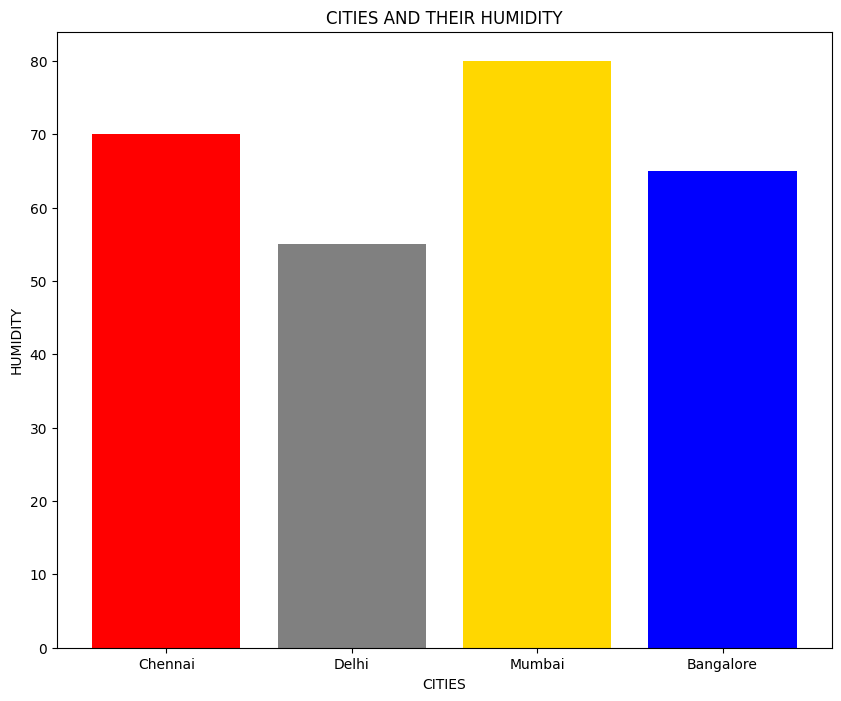

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
data = {
    'city': ['Chennai', 'Delhi', 'Mumbai', 'Bangalore'],
    'humidity': [70, 55, 80, 65]
}
pdf = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(10, 8))
ax.bar(
    pdf['city'],
    pdf['humidity'],
    color=['red', 'grey', 'gold', 'blue']
)
ax.set_xlabel("CITIES")
ax.set_ylabel("HUMIDITY")
ax.set_title("CITIES AND THEIR HUMIDITY")
plt.show()